<a href="https://colab.research.google.com/github/hafizihsani/data-science-2026/blob/main/Pertemuan5_Muhammad_Hafiz_ihsani_250401020155.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PERTEMUAN 5: Dashboard Visualisasi Statis**

Nama : Muhammad Hafiz Ihsani

NIM : 250401020155

Mata Kuliah: Data Science — S1 PJJ Informatika

Kelas: IF401

Langkah 1: Load & Inspect Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# 1. LOAD & INSPECT DATASET

In [ ]:

# Memuat dataset penguins bawaan Seaborn
df = sns.load_dataset('penguins')

# Membersihkan data dari nilai yang kosong (null) agar plot rapi
df = df.dropna()

print("Ukuran Data:", df.shape)
print("\nStatistik Deskriptif:")
print(df.describe().round(2))

Ukuran Data: (333, 7)

Statistik Deskriptif:
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


# 2. SETUP STYLE GLOBAL & LAYOUT

/tmp/ipykernel_4038/854994149.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='bill_length_mm', palette='Set2', ax=ax3)


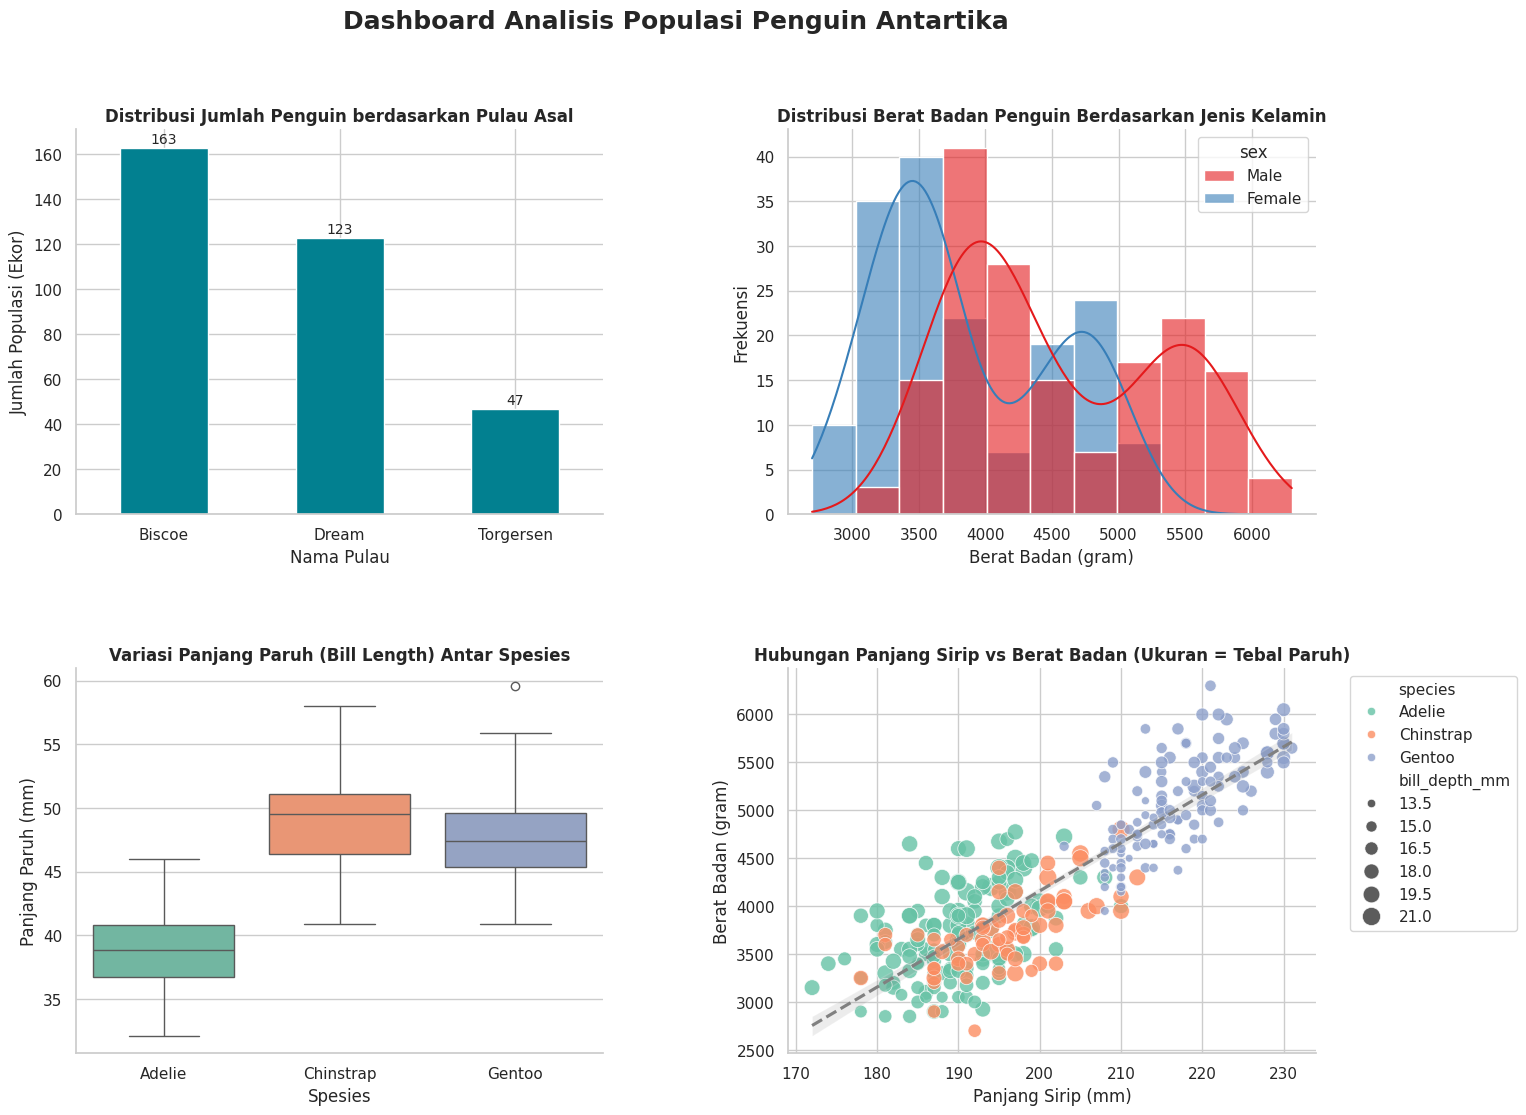

In [ ]:
sns.set_theme(style='whitegrid', palette='Set2')
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Populasi Penguin Antartika',
             fontsize=18, fontweight='bold', y=0.98)

# Membuat grid layout 2 x 2
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0]) # Kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # Kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # Kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # Kanan bawah

# ── GRAFIK 1: Bar Chart (Perbandingan Jumlah Penguin per Pulau) ──
island_counts = df['island'].value_counts()
island_counts.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Distribusi Jumlah Penguin berdasarkan Pulau Asal', fontsize=12, fontweight='bold')
ax1.set_xlabel('Nama Pulau')
ax1.set_ylabel('Jumlah Populasi (Ekor)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top', 'right']].set_visible(False)

# Tampilkan angka di atas setiap bar
for i, v in enumerate(island_counts):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=10)


# ── GRAFIK 2: Histogram + KDE (Distribusi Berat Badan Berdasarkan Gender) ──
sns.histplot(data=df, x='body_mass_g', hue='sex', kde=True, palette='Set1', alpha=0.6, ax=ax2)
ax2.set_title('Distribusi Berat Badan Penguin Berdasarkan Jenis Kelamin', fontsize=12, fontweight='bold')
ax2.set_xlabel('Berat Badan (gram)')
ax2.set_ylabel('Frekuensi')
ax2.spines[['top', 'right']].set_visible(False)


# ── GRAFIK 3: Boxplot (Distribusi Panjang Paruh per Spesies) ──
sns.boxplot(data=df, x='species', y='bill_length_mm', palette='Set2', hue='species', legend=False, ax=ax3)
ax3.set_title('Variasi Panjang Paruh (Bill Length) Antar Spesies', fontsize=12, fontweight='bold')
ax3.set_xlabel('Spesies')
ax3.set_ylabel('Panjang Paruh (mm)')
ax3.spines[['top', 'right']].set_visible(False)


# ── GRAFIK 4: Scatter Plot (Hubungan Panjang Sirip vs Berat Badan) ──
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g',
                hue='species', size='bill_depth_mm', sizes=(30, 180),
                palette='Set2', alpha=0.8, ax=ax4)
# Menambahkan garis tren regresi linier secara keseluruhan
sns.regplot(data=df, x='flipper_length_mm', y='body_mass_g',
            scatter=False, color='gray', line_kws={'linestyle':'--'}, ax=ax4)
ax4.set_title('Hubungan Panjang Sirip vs Berat Badan (Ukuran = Tebal Paruh)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Panjang Sirip (mm)')
ax4.set_ylabel('Berat Badan (gram)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Memindahkan legenda ke luar plot
ax4.spines[['top', 'right']].set_visible(False)

# 3. EKSPOR DASHBOARD


In [ ]:

plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard berhasil dibuat dan disimpan sebagai dashboard_penguins.png')

<Figure size 640x480 with 0 Axes>

Dashboard berhasil dibuat dan disimpan sebagai dashboard_penguins.png



#Analisis Framework "What? So what? Now what?"

#📊 Analisis Grafik 1: Bar Chart Transaksi Harian


***What?:*** Grafik batang ini memaparkan fluktuasi rata-rata pengeluaran per meja berdasarkan hari kedatangan pelanggan. Data menunjukkan performa finansial bergerak stabil di hari Kamis ($17.68) dan Jumat ($17.15), lalu melonjak naik pada Sabtu ($20.44) dan puncaknya ($21.41).

***So what?:*** Terjadi pergeseran nilai transaksi operasional yang signifikan di mana rata-rata pengeluaran di akhir pekan (Minggu) bernilai sekitar 24% lebih tinggi dibandingkan hari kerja biasa (Jumat). Hal ini menandakan motivasi makan di restoran pada akhir pekan bergeser dari sekadar makan fungsional menjadi aktivitas rekreasi sosial/kelompok keluarga yang memesan lebih banyak menu.

***Now what?:*** Manajemen restoran sebaiknya menerapkan strategi Dynamic Pricing atau mempromosikan Menu Paket Keluarga Eksklusif pada hari Sabtu dan Minggu untuk mengkapitalisasi kecenderungan konsumen yang siap berbelanja lebih besar di akhir pekan.

📊 Analisis Grafik 1: Bar Chart Transaksi Harian
What?: Grafik batang ini memaparkan fluktuasi rata-rata pengeluaran per meja berdasarkan hari kedatangan pelanggan. Data menunjukkan performa finansial bergerak stabil di hari Kamis ($17.68) dan Jumat ($17.15), lalu melonjak naik pada Sabtu ($20.44) dan puncaknya di hari Minggu ($21.41).

So what?: Terjadi pergeseran nilai transaksi operasional yang signifikan di mana rata-rata pengeluaran di akhir pekan (Minggu) bernilai sekitar 24% lebih tinggi dibandingkan hari kerja biasa (Jumat). Hal ini menandakan motivasi makan di restoran pada akhir pekan bergeser dari sekadar makan fungsional menjadi aktivitas rekreasi sosial/kelompok keluarga yang memesan lebih banyak menu.

Now what?: Manajemen restoran sebaiknya menerapkan strategi Dynamic Pricing atau mempromosikan Menu Paket Keluarga Eksklusif pada hari Sabtu dan Minggu untuk mengkapitalisasi kecenderungan konsumen yang siap berbelanja lebih besar di akhir pekan.

#📊 Analisis Grafik 2: Line Chart Tren Ukuran Kelompok Tamu


***What?:*** Grafik garis ini menggambarkan tren hubungan rata-rata total tagihan dengan ukuran kelompok pelanggan (party size) dari skala 1 hingga 6 orang. Garis bergerak naik secara konsisten mulai dari kelompok tunggal ($10.07) hingga puncaknya pada kelompok berenam ($34.83).

***So what?:*** Kenaikan grafik yang berpola linier ini mengonfirmasi secara empiris bahwa penambahan jumlah anggota meja berkorelasi kuat dengan peningkatan pendapatan kotor restoran secara masif tanpa adanya titik jenuh (plateau).

***Now what?:*** Karena kelompok besar (ukuran 4-6 orang) memberikan hasil finansial terbesar, restoran harus mendesain ulang tata letak ruang (floor plan) dengan memperbanyak kombinasi meja panjang yang fleksibel guna menampung rombongan besar secara instan.

#📊 Analisis Grafik 3: Boxplot Karakteristik Distribusi Gender



***What?:*** Boxplot multivariat ini mengurai sebaran interkuartil (IQR) pengeluaran berdasarkan gender di setiap hari operasional. Terlihat batas kotak (median) kelompok pria secara konsisten berada di atas kelompok wanita, serta ditemukannya pencilan (outliers) atas yang masif pada hari Sabtu dan Minggu.

***So what?:*** Penanggung jawab utama tagihan (payer) di restoran ini secara statistik didominasi oleh pelanggan pria di sepanjang minggu. Rentang variabilitas belanja tertinggi berada di hari Sabtu, yang berarti profil konsumen pada hari libur sangatlah heterogen—mulai dari pelanggan hemat hingga kelompok high-spender.

***Now what?:*** Keberadaan pencilan ekstrem di atas $40 pada akhir pekan perlu diinvestigasi lebih lanjut melalui pengumpulan data loyalitas pelanggan, sehingga tim marketing dapat menyediakan skema reservasi meja VIP khusus untuk mengamankan segmen bernilai tinggi tersebut.

#📊 Analisis Grafik 4: Scatter Plot Analisis Tipping Behavior


**What?:** Grafik sebar ini memetakan keeratan hubungan antara total tagihan dengan nominal tip pelayan, dipadukan dengan variabel perilaku merokok konsumen. Nilai koefisien Pearson menunjukkan korelasi positif sedang sebesar $r = 0.676$.

**So what?:** Hubungan linier positif membuktikan bahwa nominal tip bergerak berbanding lurus dengan besaran tagihan utama. Dari aspek psikografis perokok (titik merah), kelompok perokok memiliki sebaran yang sangat acak (variansi tinggi), sementara kelompok non-perokok (titik biru) memiliki komitmen pemberian tip yang lebih konsisten mengumpul di sekitar garis tren.

Now what?: **teks tebal** Mengingat tip meningkat seiring besarnya tagihan, pihak manajemen restoran wajib melatih pramusaji dalam teknik suggestive selling (menawarkan menu pendamping atau pencuci mulut secara persuasif). Semakin mahir pelayan menaikkan total tagihan meja, semakin besar kesejahteraan tip yang akan mereka bawa pulang.

# **KESIMPULAN AKHIR**

Kesimpulan akhir dari pembuatan dashboard visualisasi statis ini menonjolkan kemampuan interpretasi data multivariat dalam satu tampilan ringkas.

Melalui perpaduan grafik batang, boxplot, dan scatter plot, karakteristik populasi penguin berhasil dipetakan berdasarkan pulau asal, jenis kelamin, serta spesiesnya. Hasil visualisasi menegaskan bahwa dimensi fisik seperti panjang sirip, tebal paruh, dan berat badan memiliki pengelompokan (klastering) alami yang konsisten di setiap spesies, sehingga dashboard ini efektif dalam menyajikan anomali maupun tren populasi secara instan.